# Muestreo Estratificado / Incremental

En este código se muestra un muestreo estratificado a un conjunto de datos con comportamiento no normal en un espacio 2D.

### Construcción de la Población simulada

Se construye con conjunto de datos no balanceado en clases y no-normal (datos que no generan una hiper-esfera en el hiper-espacio).

In [3]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')

In [4]:
from sklearn.datasets import make_blobs

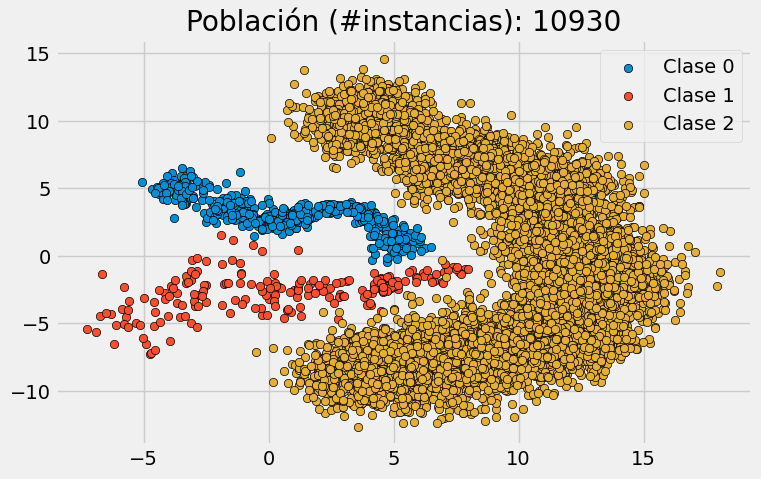

In [5]:
# se genera una población con tres clases desbalanceadas y una distribución
# no normal en los datos
import matplotlib.pyplot as plt
# generación de la clase 0
samples = [80, 100, 50, 70, 40, 40, 50, 90]
centroids = [(-3.5,5),(-1.5,3.5),(0,2.5), (1.2,3), (2.5, 3.5),(3.5,3.5),(4,2.8),(5,1)]
std = [0.6, 0.7, 0.5, 0.4, 0.2, 0.2, 0.4, 0.6]
population_c1, population_c1_lables = make_blobs(n_samples= samples, cluster_std=std, centers=centroids, random_state=42)
population_c1_lables = np.full_like(population_c1_lables,0)

# generación de la clase 1
samples = [30, 25, 35, 25, 30, 40, 15, 10]
centroids = [(-5.0,-4.7), (-3.0,-2.5), (-1.5,-2.5), (0.7,-3.0), (2.8, -2.5), (4.6, -2.2), (6.2, -1.7), (7.5,-1.0)]
std = [1.3, 1.4, 1.5, 0.9, 0.8, 0.45, 0.35, 0.3]
population_c2, population_c2_lables = make_blobs(n_samples= samples, cluster_std=std, centers=centroids, random_state=42)
population_c2_lables = np.full_like(population_c2_lables,1)

# generación de la clase 3
samples = [1000, 1400, 1300, 1000, 1200, 1400, 1300, 1600]
centroids = [(4.0,10.0), (7.5,7), (11, 5), (12.0, 1.0), (13, -2), (11.5, -6.2), (8, -7.5), (4.5,-8.5)]
std = [1.2, 1.1, 1.3, 1.2, 1.5, 1.2, 1.6, 1.3]
population_c3, population_c3_lables = make_blobs(n_samples= samples, cluster_std=std, centers=centroids, random_state=42)
population_c3_lables = np.full_like(population_c3_lables,2)

population = population_c1
population_lables = population_c1_lables
population = np.append(population, population_c2, axis=0)
population_lables = np.append(population_lables, population_c2_lables, axis=0)
population = np.append(population, population_c3, axis=0)
population_lables = np.append(population_lables, population_c3_lables, axis=0)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for i in np.unique(population_lables):
    ax.scatter(
        x = population[population_lables == i, 0],
        y = population[population_lables == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= f"Clase {i}"
    )

title = 'Población (#instancias): ' + str(len(population))
ax.set_title(title)
ax.legend()


Se genera un dataframe con los datos de la población

In [6]:
#se construye un dataframe de pandas a partir del arreglo X de datos
df_population = pd.DataFrame(population)
#Se añade la columna clase al dataframe
df_population['class'] = pd.DataFrame(population_lables)
df_population

,0,1,class
0,4.594165,2.080564,0
1,5.221204,0.763997,0
2,4.459709,2.518729,0
3,3.603532,3.354851,0
4,4.867421,1.016132,0
...,...,...,...
10925,5.886536,6.448458,2
10926,11.506549,-8.033097,2
10927,4.103908,9.813187,2
10928,8.714327,6.718091,2


In [7]:
# se imprime estadística general sobre la población
df_population.describe()

,0,1,class
count,10930.000000,10930.000000,10930.000000
mean,8.311527,-0.546099,1.885636
std,3.959572,6.554100,0.443231
min,-7.242393,-12.659044,0.000000
25%,5.260715,-6.787364,2.000000
50%,8.654417,-0.985207,2.000000
75%,11.593052,5.499911,2.000000
max,18.066652,14.623278,2.000000


In [8]:
#se imprime el IQR (Rango InterQuantil) de los descriptores
IQR_0 = df_population[0].quantile(0.75) - df_population[0].quantile(0.25)
IQR_1 = df_population[1].quantile(0.75) - df_population[1].quantile(0.25)
print("IQR atrib 0: ", IQR_0)
print("IQR atrib 1: ", IQR_1)

IQR atrib 0:  6.332337017898274
IQR atrib 1:  12.287275079948028


### Construcción de una muestra estratificada multietapa

Se procede a construir una Muestra de la Población. Primero se se va a calcular parámetros estadísticos de cada descriptor, de tal forma que se identifique el momento en el cual las variables se estabilizan.

In [9]:
# se generan muestras de diferente tamaño (partiendo de un tamaño delta e incrementando delta en delta)
# se calcula la media de cada atributo para cada tamaño de muestra
statistics_global = []
delta = 100
df_sample_n = pd.DataFrame()
df_pob = df_population.copy()
max = len(df_pob)

for i in range(delta, max, delta):
    #se genera una muestra de la poblacion
    df_tmp = df_pob.sample(n = delta)
    df_sample_n = pd.concat([df_sample_n, df_tmp])
    #se eliminan los registros de la muestra de la población
    df_pob = df_pob.drop(df_tmp.index)
    #se separan los datos por clases
    df_sample_classes = []
    for j in np.unique(df_sample_n['class']):
        df_sample_classes.append(df_sample_n[df_sample_n['class'] == j])

    #se calcula la media de cada columna de df_sample_classes
    for k in range(len(df_sample_classes)):
        statistics_global.append([df_sample_classes[k][0].mean(), df_sample_classes[k][1].mean(),k,i])

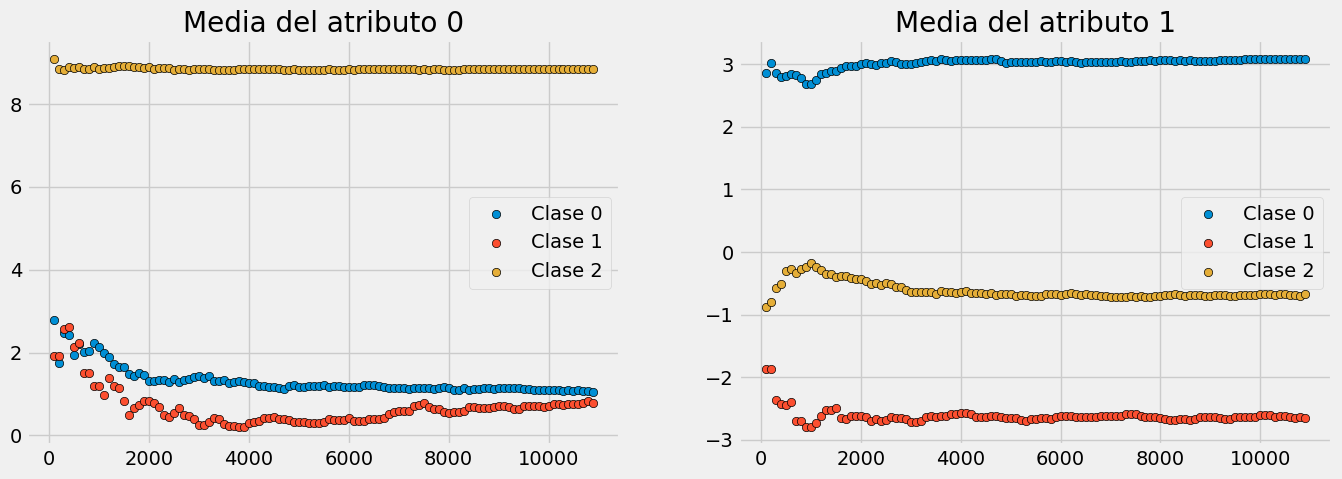

In [10]:
# se grafica como se comporatan las variaciones de la media, como medida de estabilidad de la muestra
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax = ax.flatten()
for i in range(0,3):
    ax[0].scatter(
        x = [t[3] for t in statistics_global if t[2] == i],
        y = [t[0] for t in statistics_global if t[2] == i],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= f"Clase {i}"
    )
ax[0].set_title('Media del atributo 0')
ax[0].legend()

for i in range(0,3):
    ax[1].scatter(
        x = [t[3] for t in statistics_global if t[2] == i],
        y = [t[1] for t in statistics_global if t[2] == i],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= f"Clase {i}"
    )

ax[1].set_title('Media del atributo 1')
ax[1].legend()

In [11]:
# CONSTRUCCION DE LA MUESTRA
# Aquí se define el tamaño de la muestra a generar usando como información las métricas previas
# idealmente se debe proponer un tamaño de muestra a partir del cual se estabilizan las métricas
sample_size = 1500
df_sample_random = df_population.sample(n = sample_size)

df_sample_random

,0,1,class
8419,5.299661,11.264562,2
8590,12.244496,4.862082,2
5922,12.279498,-6.611261,2
454,-4.044814,4.152618,0
4883,13.790009,1.869795,2
...,...,...,...
6542,11.702455,0.424038,2
2196,3.915801,8.006847,2
10447,1.790951,8.464508,2
9256,9.774559,-7.667635,2


In [12]:
#se separan las instancias para poder imprimirse en pantalla
sample_random = df_sample_random[[0,1]].to_numpy()
sample_random_lables = df_sample_random['class'].to_numpy()

1500


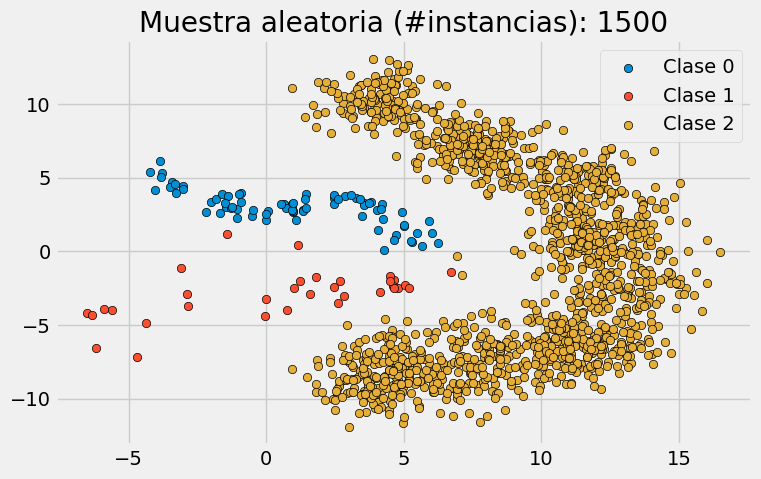

In [13]:
# se genera la grafica de la muestra aleatoria que se ha construido
print(len(sample_random))
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for i in np.unique(sample_random_lables):
    ax.scatter(
        x = sample_random[sample_random_lables == i, 0],
        y = sample_random[sample_random_lables == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= f"Clase {i}"
    )

title = 'Muestra aleatoria (#instancias): ' + str(len(sample_random))
ax.set_title(title)
ax.legend()

### Construyendo un training y test aleatorio de la Población

Para tener un punto de compración cuando se trabaje con la muestra, se va a construir para este ejemplo un training y test sobre la población con un muestreo aleatorio simple, simulando que sucedería en el hipotético caso que se tuviera acceso a toda la población.

Para los ejemplos se va a trabajar con un: training (80%) y un test (80%)

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
# Se genera la división 80% - 20% con un muestreo aleatorio simple sobre la población
train_pop_rand, test_pop_rand, train_pop_rand_lables, test_pop_rand_lables = train_test_split(population, population_lables, test_size = 0.2)

### Construyendo un training y un test 80 - 20 de la muestra aleatoria (con un muestreo aleatorio)

In [16]:
train_sam_rand, test_sam_rand, train_sam_rand_lables, test_sam_rand_lables = train_test_split(sample_random, sample_random_lables, test_size = 0.2)


### Gráficas del training-test de la población y training-test de la muestra

Se generan las gráficas para poder visualizar como quedó el conjunto training y el conjunto test de la población (escenario hipotético dónde se tiene acceso al total de la población)

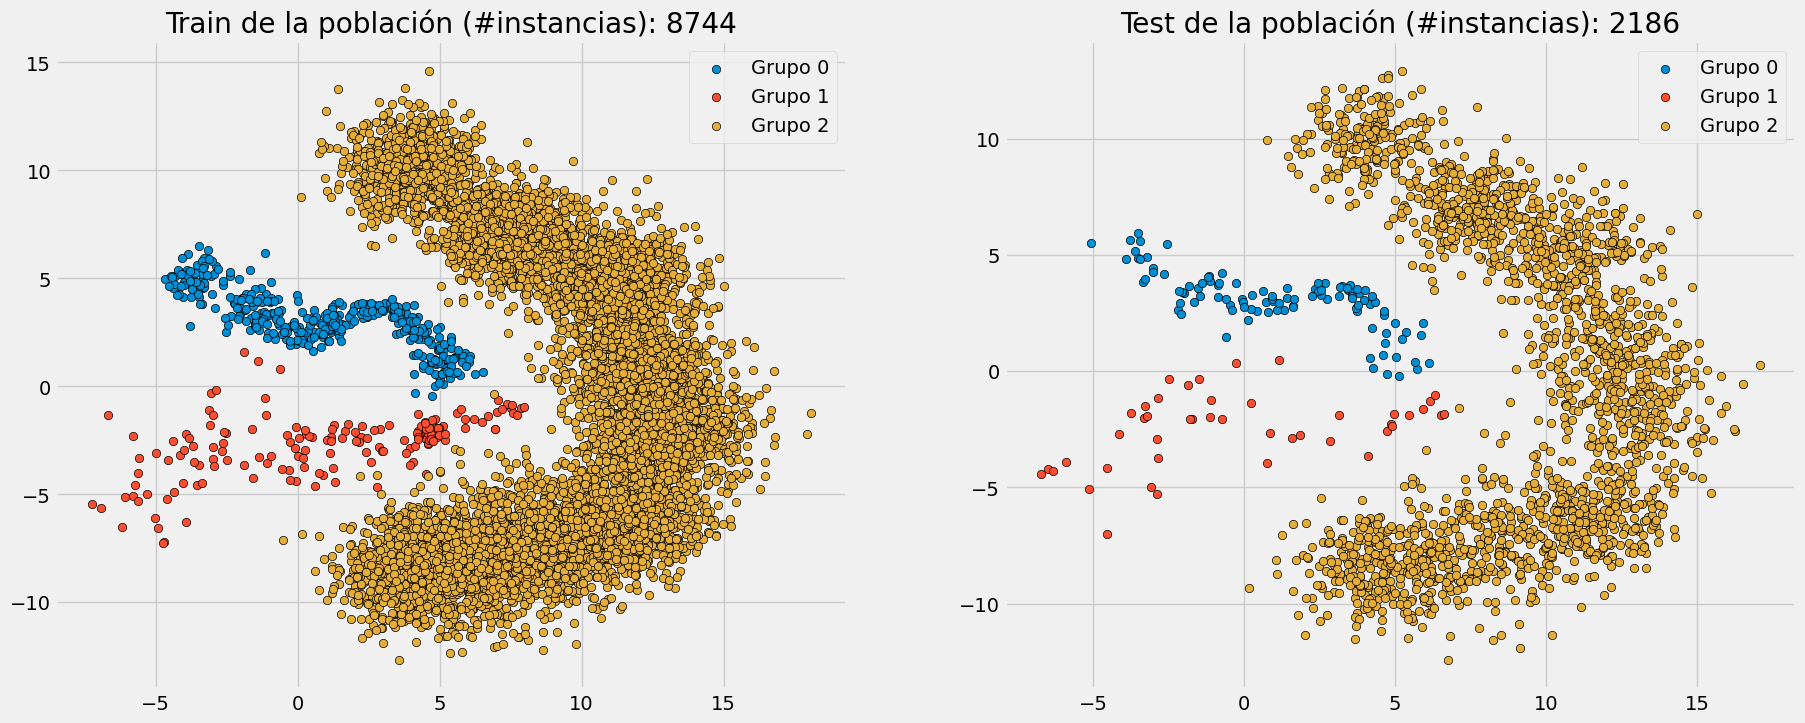

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
ax = ax.flatten()
for i in np.unique(train_pop_rand_lables):
    ax[0].scatter(
        x = train_pop_rand[train_pop_rand_lables == i, 0],
        y = train_pop_rand[train_pop_rand_lables == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= f"Grupo {i}"
    )
legend = 'Train de la población (#instancias): ' + str(len(train_pop_rand))
ax[0].set_title(legend)
ax[0].legend()

for i in np.unique(test_pop_rand_lables):
    ax[1].scatter(
        x = test_pop_rand[test_pop_rand_lables == i, 0],
        y = test_pop_rand[test_pop_rand_lables == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= f"Grupo {i}"
    )
legend = 'Test de la población (#instancias): ' + str(len(test_pop_rand))
ax[1].set_title(legend)
ax[1].legend()


Se imprimen las gráficas del training - test (80 - 20) generado con un muestreo aleatorio

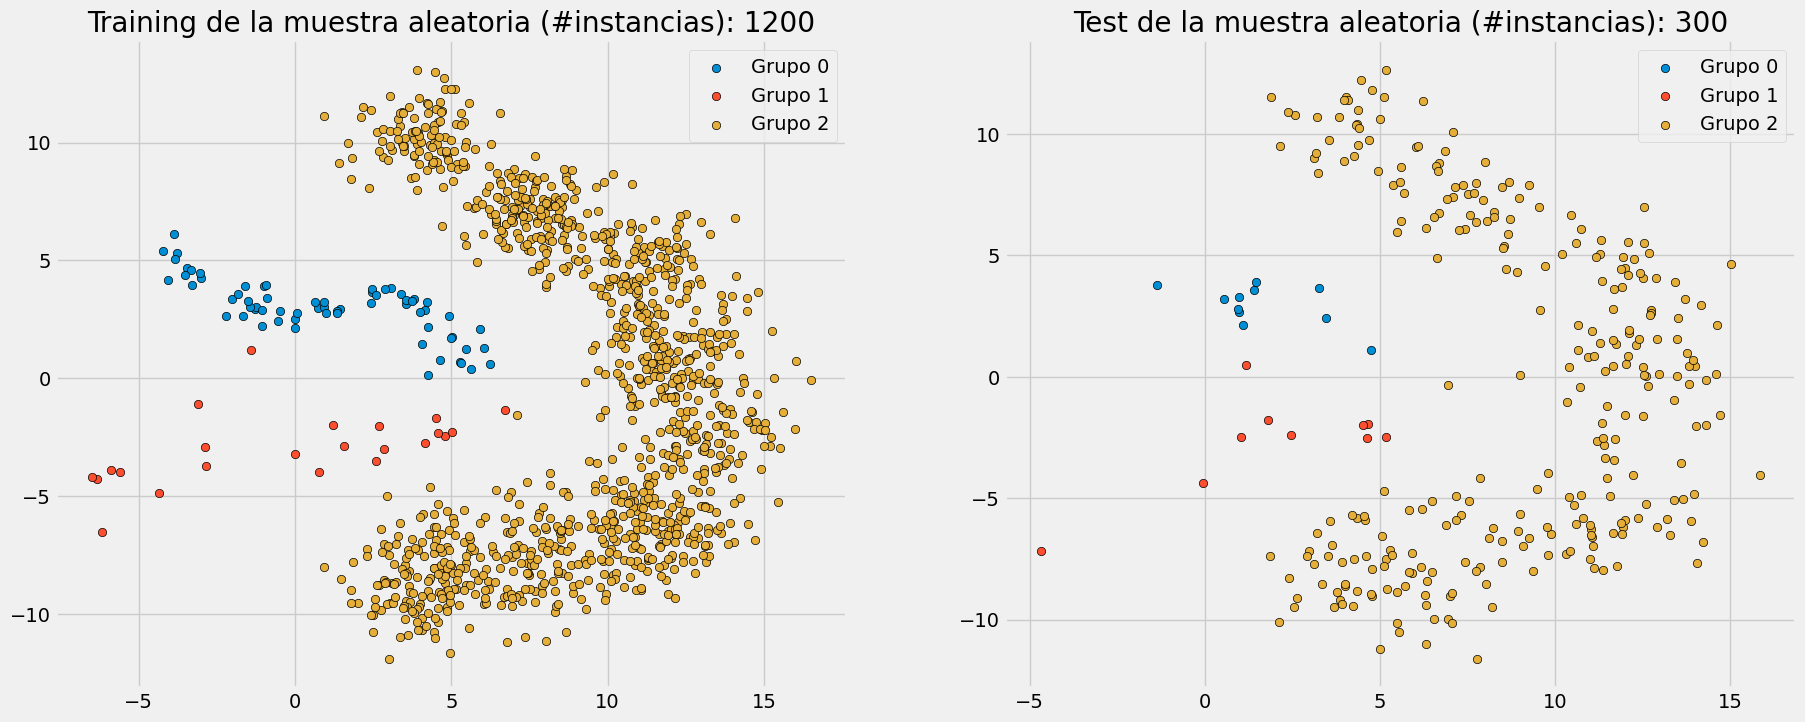

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
ax = ax.flatten()
for i in np.unique(train_sam_rand_lables):
    ax[0].scatter(
        x = train_sam_rand[train_sam_rand_lables == i, 0],
        y = train_sam_rand[train_sam_rand_lables == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= f"Grupo {i}"
    )
legend = 'Training de la muestra aleatoria (#instancias): ' + str(len(train_sam_rand))
ax[0].set_title(legend)
ax[0].legend()

for i in np.unique(test_sam_rand_lables):
    ax[1].scatter(
        x = test_sam_rand[test_sam_rand_lables == i, 0],
        y = test_sam_rand[test_sam_rand_lables == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= f"Grupo {i}"
    )
legend = 'Test de la muestra aleatoria (#instancias): ' + str(len(test_sam_rand))
ax[1].set_title(legend)
ax[1].legend()


### Construyendo un training y un test de la población con un MUESTREO ESTRATIFICADO SIN BALANCEO

In [31]:
# se calcula el porcentaje de sample_size con respecto al tamaño de la población
proportion = sample_size / len(population)
print(proportion)
# Se construye un muestreo estratificado sin balanceo de la poblacion
# groupby.sample preserva la columna 'class' en el resultado
df_sample_stratify = df_population.groupby('class', group_keys=False).sample(frac=proportion)

0.1372369624885636


In [32]:
# se generan los arreglos numpay de las instancias de la muestra estratificada
sample_stratify = df_sample_stratify[[0,1]].to_numpy()
sample_stratify_lables = df_sample_stratify['class'].to_numpy()
#se construye un training - test del 80 - 20 estratificado
train_sam_str, test_sam_str, train_sam_str_lables, test_sam_str_lables = train_test_split(sample_stratify, sample_stratify_lables, test_size = 0.2, stratify = sample_stratify_lables)


Se generan las graficas para observar como quedan los conjuntos training y test de un muestreo estratificado.

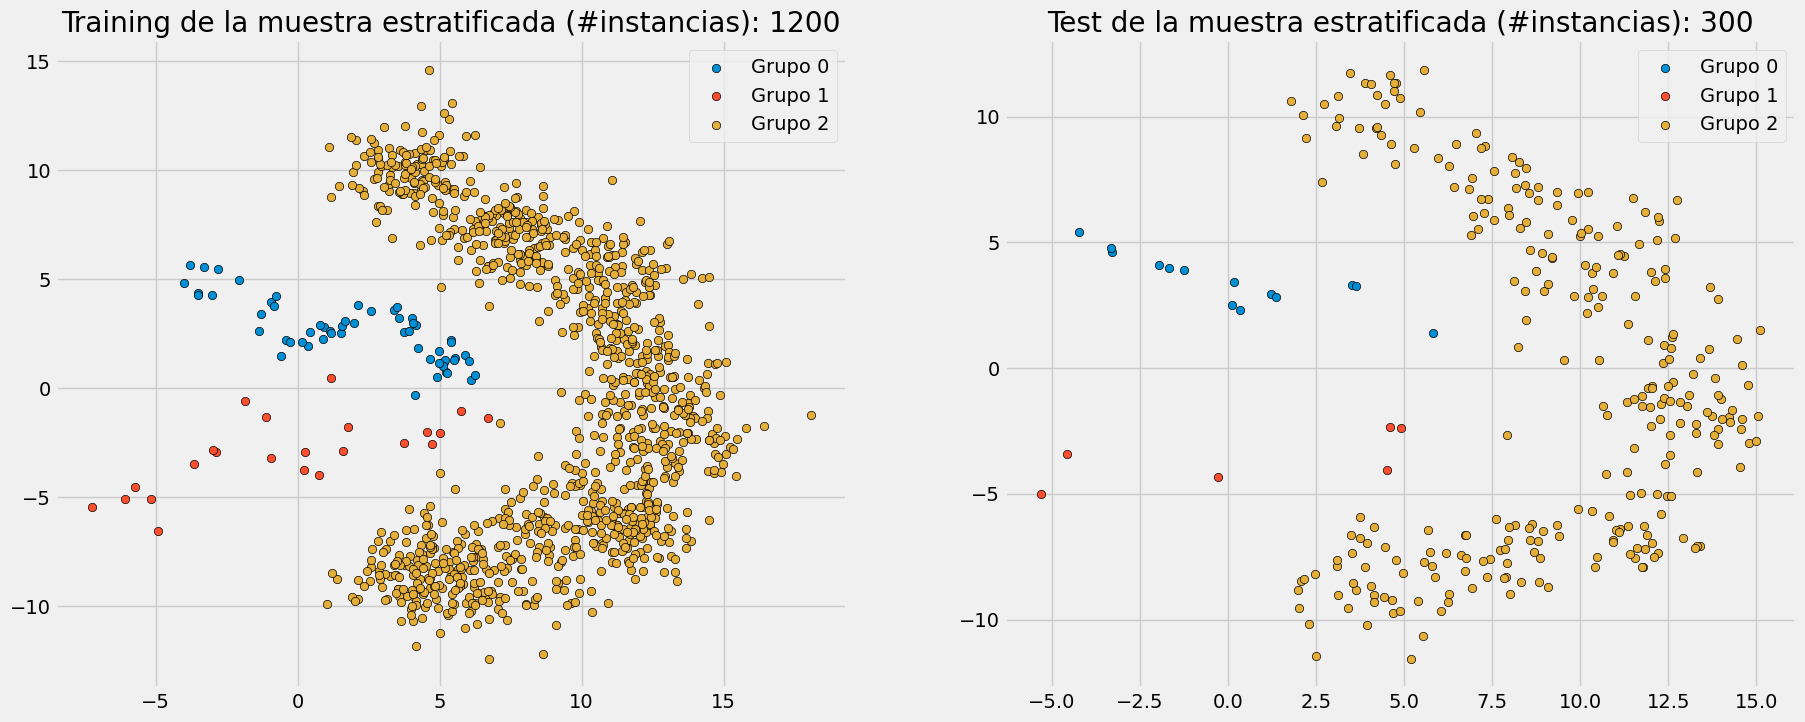

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
ax = ax.flatten()
for i in np.unique(train_sam_str_lables):
    ax[0].scatter(
        x = train_sam_str[train_sam_str_lables == i, 0],
        y = train_sam_str[train_sam_str_lables == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= f"Grupo {i}"
    )
legend = 'Training de la muestra estratificada (#instancias): ' + str(len(train_sam_str))
ax[0].set_title(legend)
ax[0].legend()

for i in np.unique(test_sam_str_lables):
    ax[1].scatter(
        x = test_sam_str[test_sam_str_lables == i, 0],
        y = test_sam_str[test_sam_str_lables == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= f"Grupo {i}"
    )
legend = 'Test de la muestra estratificada (#instancias): ' + str(len(test_sam_str))
ax[1].set_title(legend)
ax[1].legend()


In [34]:
print("Dimensión de clase 1 en población: ", len(df_population[df_population['class'] == 1]))
print("Dimensión de clase 1 en muestra aleatoria: ", len(df_sample_random[df_sample_random['class'] == 1]))
print("Dimensión de clase 1 en muestra estratificada: ", len(df_sample_stratify[df_sample_stratify['class'] == 1]))

Dimensión de clase 1 en población:  210
Dimensión de clase 1 en muestra aleatoria:  33
Dimensión de clase 1 en muestra estratificada:  29


Comparando los muestreos 80 - 20 sobre la población con aleatorio simple y estratificado

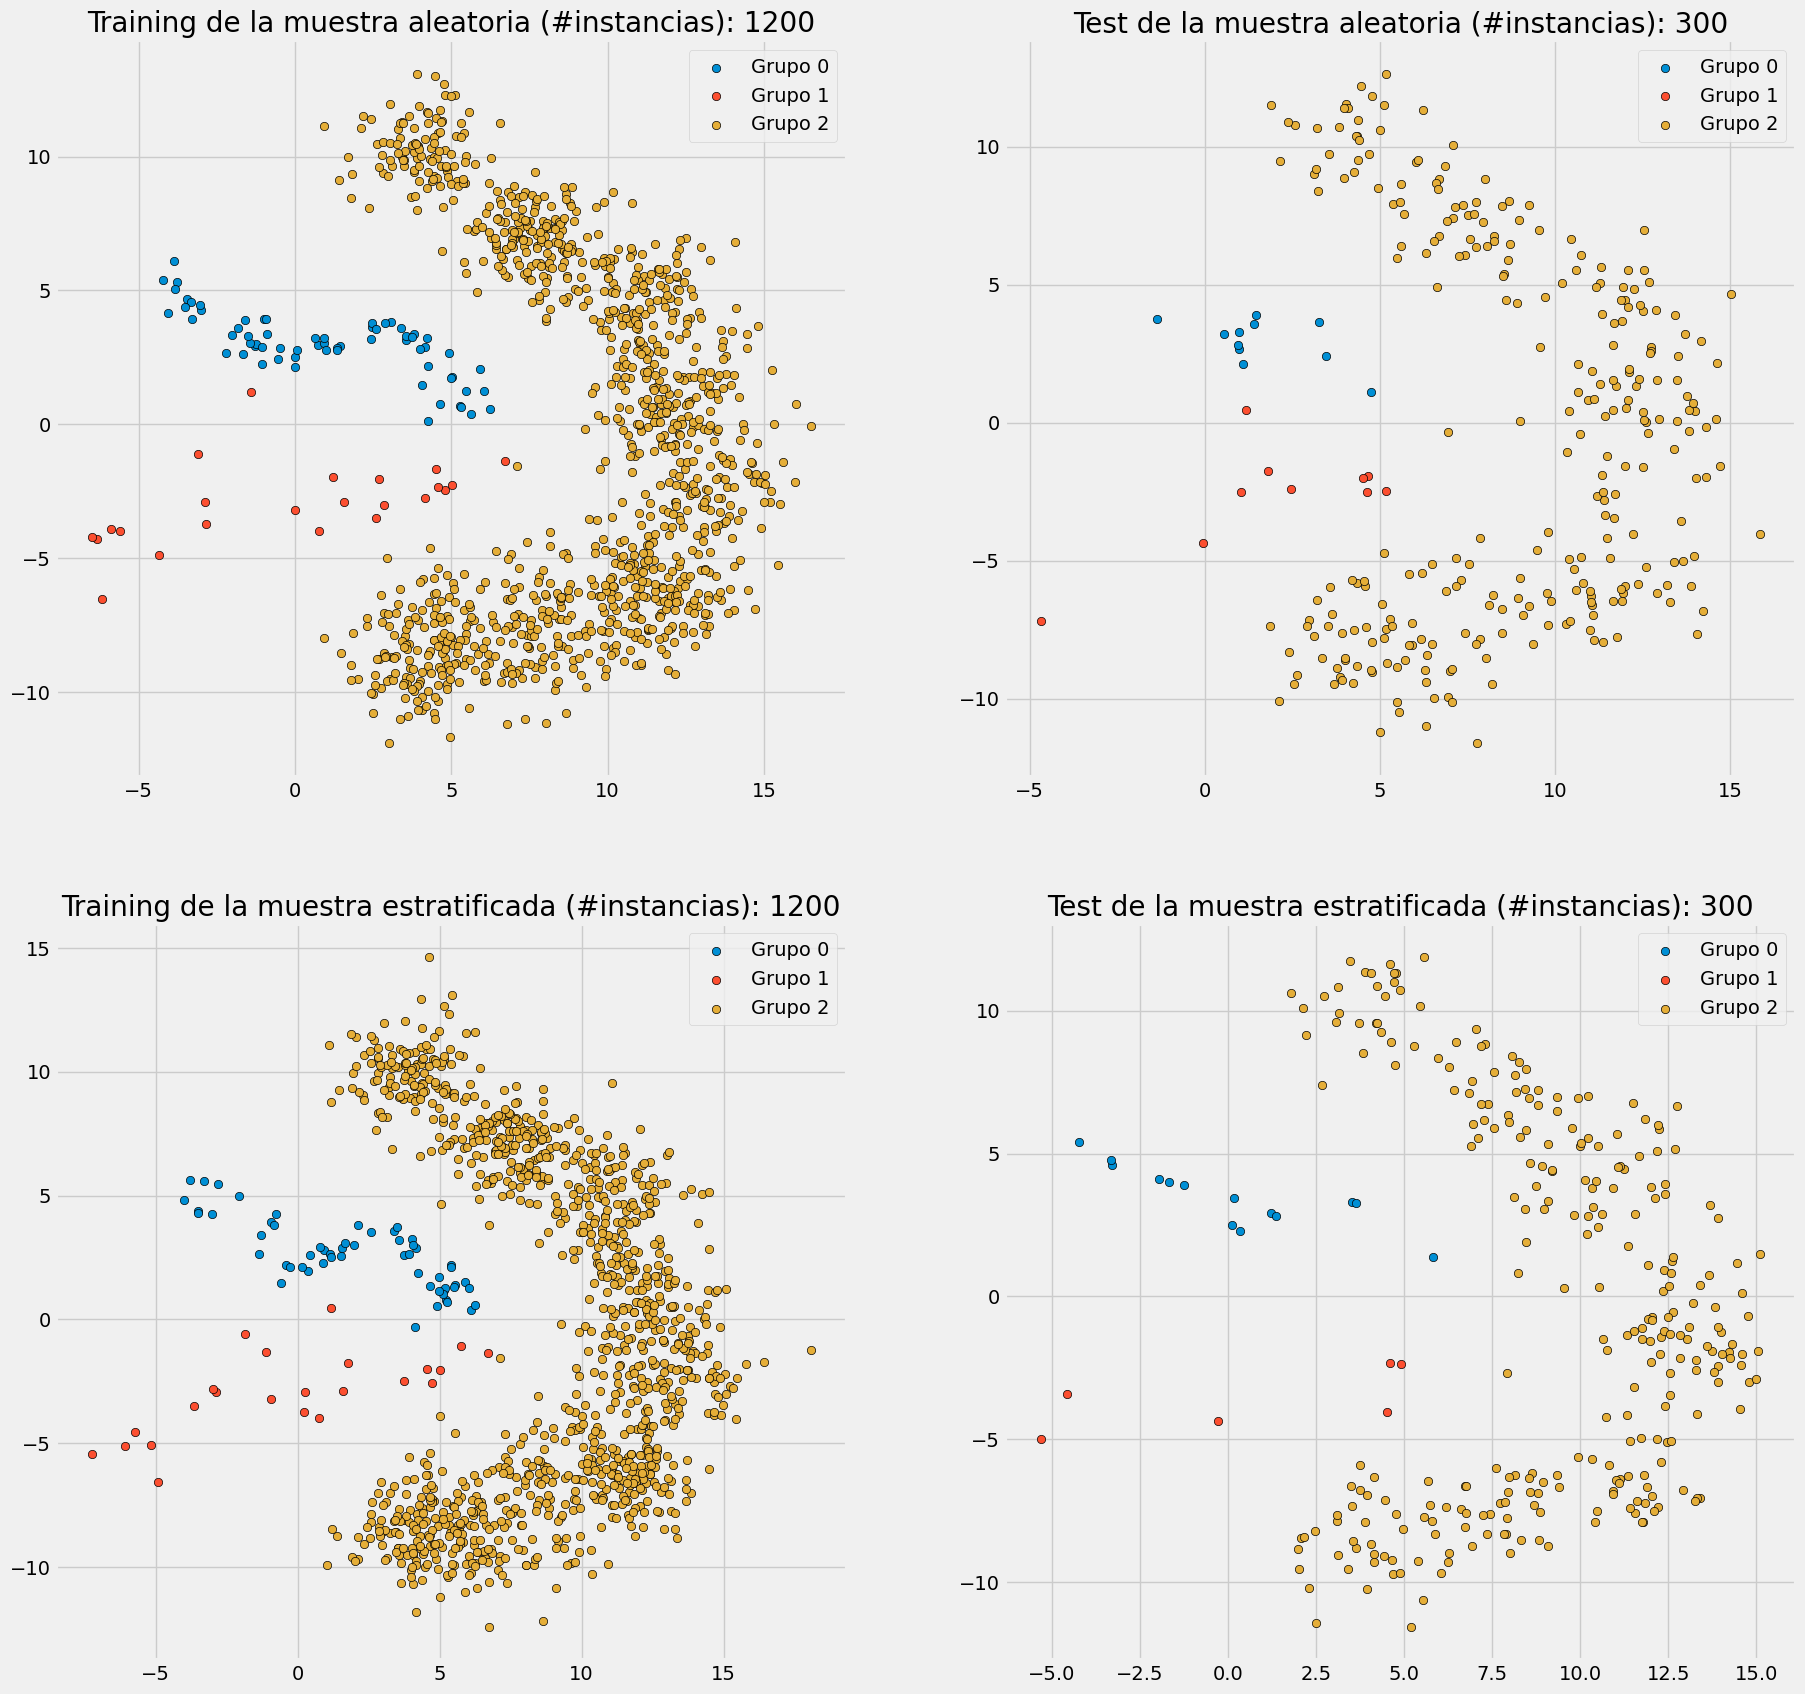

In [35]:
fig, ax = plt.subplots(2, 2, figsize=(20, 20))
#ax = ax.flatten()
#graficas de la muestra aleatoria
for i in np.unique(train_sam_rand_lables):
    ax[0][0].scatter(
        x = train_sam_rand[train_sam_rand_lables == i, 0],
        y = train_sam_rand[train_sam_rand_lables == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= f"Grupo {i}"
    )
legend = 'Training de la muestra aleatoria (#instancias): ' + str(len(train_sam_rand))
ax[0][0].set_title(legend)
ax[0][0].legend()

for i in np.unique(test_sam_rand_lables):
    ax[0][1].scatter(
        x = test_sam_rand[test_sam_rand_lables == i, 0],
        y = test_sam_rand[test_sam_rand_lables == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= f"Grupo {i}"
    )
legend = 'Test de la muestra aleatoria (#instancias): ' + str(len(test_sam_rand))
ax[0][1].set_title(legend)
ax[0][1].legend()

#graficas de la muestra estratificada
for i in np.unique(train_sam_str_lables):
    ax[1][0].scatter(
        x = train_sam_str[train_sam_str_lables == i, 0],
        y = train_sam_str[train_sam_str_lables == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= f"Grupo {i}"
    )
legend = 'Training de la muestra estratificada (#instancias): ' + str(len(train_sam_str))
ax[1][0].set_title(legend)
ax[1][0].legend()

for i in np.unique(test_sam_str_lables):
    ax[1][1].scatter(
        x = test_sam_str[test_sam_str_lables == i, 0],
        y = test_sam_str[test_sam_str_lables == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= f"Grupo {i}"
    )
legend = 'Test de la muestra estratificada (#instancias): ' + str(len(test_sam_str))
ax[1][1].set_title(legend)
ax[1][1].legend()